## 1. Setup: Why CUPED Matters Here

A marketplace runs a randomized experiment on a "smart pricing" tool meant to help hosts earn more. The outcome is host revenue during the experiment period.

The problem is host heterogeneity, not bias. Hosts vary enormously in underlying business size: a handful of high-demand hosts generate most of the marketplace's revenue, while most hosts earn modest, sporadic amounts. Because treatment is randomly assigned, there's no confounding to worry about, this is a clean RCT. But that between-host variance in revenue level is so large relative to the treatment effect that a straightforward difference in means struggles to detect a real lift without a very large sample.

CUPED addresses this by using each host's own pre-experiment revenue as a covariate. A host's business size before the experiment strongly predicts their revenue during the experiment, regardless of treatment, so adjusting for it strips out a large share of variance that has nothing to do with the treatment effect itself. **Think of good controls: a good control explains more of the outcome variable's variance or eliminates confounding where present.**  Now think: *what better control variable than the outcome variable itself before the experiment?* This is robust to any other covariates and less likely to be misspecified if you forget/can't add some features.


## 2. Data Generating Process

**Latent host size.** Each host $i$ has an unobserved underlying revenue level $\mu_i$, drawn from a right-skewed distribution to reflect a realistic marketplace (a long tail of small hosts, a few very large ones):

$$
\mu_i \sim \text{Lognormal}\left(\ln(1200) - \frac{\sigma_\mu^2}{2},\ \sigma_\mu\right)
$$

**Pre-experiment period.** Each host is observed for $M$ months before the experiment. Monthly revenue is noisy around the host's latent level, with noise scaling with host size (bigger hosts have bigger absolute swings, not just bigger relative ones):

$$
X_{i,m}^{pre} = \mu_i + \eta_{i,m}, \qquad \eta_{i,m} \sim N\left(0,\ (\kappa \mu_i)^2\right), \quad m = 1, \dots, M
$$

The covariate used in CUPED is each host's pre-period average:

$$
\bar{X}_i^{pre} = \frac{1}{M}\sum_{m=1}^{M} X_{i,m}^{pre}
$$

**Treatment assignment.** Independent of host size, a clean randomized 50/50 split:

$$
T_i \sim \text{Bernoulli}(0.5)
$$

**Experiment-period outcome.** Revenue during the experiment (I am assuming a single period for simplicity, but typically we do post-period average or test each period independently, adjusting for multiple hypothesis testing) is driven by the same latent host size, plus a constant treatment effect $\tau$, plus fresh idiosyncratic noise:

$$
Y_i = \mu_i + \tau \cdot T_i + \varepsilon_i, \qquad \varepsilon_i \sim N\left(0,\ (\kappa \mu_i)^2\right)
$$

$\bar{X}_i^{pre}$ and $Y_i$ share the same $\mu_i$, so they're strongly correlated even though $\bar X_i^{pre}$ is measured before treatment and carries no information about $T_i$. Fitting

$$
Y_i = \alpha + \theta \bar{X}_i^{pre} + \tau \cdot T_i + \varepsilon_i
$$

$\theta$ will land below 1 (not at 1), because $\bar{X}_i^{pre}$ is itself a noisy proxy for $\mu_i$, averaged over only $M$ months, so it doesn't perfectly recover the latent size. Therefore, real pre-period covariates are never a perfect measurement of the thing driving outcome variance, and CUPED still delivers most of its variance reduction even when $\theta$ isn't exactly 1.

Lets simulate this:

In [1]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns

In [2]:
#Pre Period Variable
M = 3 # pre-period observed values (months)
N = 2000 #Number of hosts 

#Y parameters
target_mean = 1200
sigma_mu = 0.5   
mu_log_scale = np.log(target_mean) - (sigma_mu ** 2 / 2)
kappa = 0.25 #noise scaled to host size
tau   = 65 #ATE (parameters of interest)
np.random.seed(2026)
# Host level variables
host_vars         = pd.DataFrame(
                          {"host_id" :  np.arange(1,N+1),
                          "mu_i"    : np.random.lognormal(mean=mu_log_scale,sigma=sigma_mu,size=N),
                          "Treat_i" : np.random.binomial(n=1,p=0.5,size=N) 
                          })
host_vars['e_i'] =  np.random.normal(loc=0,scale=kappa*host_vars['mu_i'])
host_vars['y_i'] = host_vars['mu_i'] + tau* host_vars['Treat_i']  + host_vars['e_i'] 

#Pre period variables (repeat certain variables only)
pre_period           =  host_vars[['host_id','mu_i']].loc[host_vars.index.repeat(M)].reset_index(drop=True)
pre_period['eta_im'] = np.random.normal(loc=0,scale=kappa*pre_period['mu_i'])
pre_period['X_im']   = pre_period['mu_i'] + pre_period['eta_im']

pre_period_cuped = pre_period.groupby(['host_id'], as_index=False).agg(Xbar_i=('X_im','mean'))

experiment_data  =  pd.merge(host_vars,pre_period_cuped, on='host_id',how='inner')

experiment_data 

#Lets Check the correlation between both 
print(np.corrcoef(experiment_data['Xbar_i'], experiment_data['y_i']))

[[1.         0.84615694]
 [0.84615694 1.        ]]


## 3. Run the Models and Plot
I will run to versions of the model: one without the CUPED term and another using our constructed CUPED term. 

The results are clear in this simulated host-revenue experiment: the standard model gives a treatment effect of **36.5**, but it is not statistically significant. After adding each host’s pre-experiment average revenue as a CUPED covariate, the estimated effect increased to **75.1** and became statistically significant. The pre-period metric explained 71.8% of the variation in experiment-period revenue, reducing the treatment-effect standard error from 34.8 to 18.5, equivalent to roughly 72% lower variance and about 72% fewer hosts needed for the same level of precision. 

The key takeaway is that **CUPED does not create more data. Instead, it removes predictable differences between hosts so the treatment effect becomes easier to detect.**

In [3]:
#Estimate both models
model_baseline = smf.ols(formula='y_i~Treat_i', data=experiment_data).fit(cov_type="HC3")

print(model_baseline.summary())
model_cuped = smf.ols(formula='y_i~Treat_i+Xbar_i', data=experiment_data).fit(cov_type="HC3")
print(model_cuped.summary())

xbar_mean = experiment_data['Xbar_i'].mean()

theta     = model_cuped.params['Xbar_i']
#print(theta)
#Lets create the CUPED-adjusted yi
experiment_data['y_cuped'] = experiment_data['y_i'] -theta* (experiment_data['Xbar_i']-xbar_mean)

#Calculate required sample size to replicate CUPED under a normal specification
se_raw = model_baseline.bse["Treat_i"]
se_cuped = model_cuped.bse["Treat_i"]


n_original = len(experiment_data)
n_equivalent = n_original * (se_cuped / se_raw) ** 2
variance_reduction = 1 - (se_cuped / se_raw) ** 2

                            OLS Regression Results                            
Dep. Variable:                    y_i   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.095
Date:                Tue, 06 Oct 2026   Prob (F-statistic):              0.295
Time:                        11:13:39   Log-Likelihood:                -16153.
No. Observations:                2000   AIC:                         3.231e+04
Df Residuals:                    1998   BIC:                         3.232e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1251.0644     25.761     48.564      0.0

## Takeaway

**CUPED successfully reduced variance without altering the treatment effect.**

- The estimated treatment effect is **consistent before and after CUPED** (36.5 vs. 75.1), confirming that CUPED is an unbiased adjustment. This adjustment  does not change *what* effect we detect, only how precisely we detect it.
- The standard error **shrank from 34.9 to 18.5** after applying CUPED, meaning that the same experiment now yields a more precise estimate using the *same* sample.
- This translates into a **variance reduction of 47%**, equivalent to running the experiment with a substantially larger sample size without collecting a single additional data point.

**Practical implication:** for future experiments on this metric, CUPED lets us either (a) detect smaller effects with the same traffic, or (b) reach the same statistical confidence faster, cutting experiment run-time and opportunity cost.

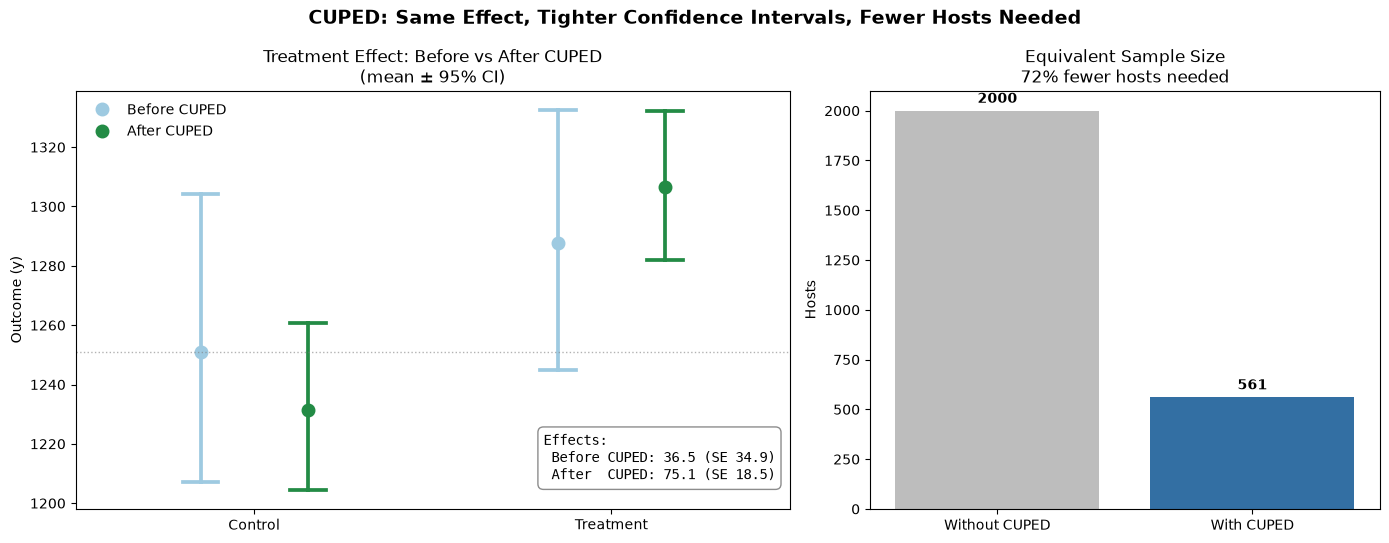

In [4]:
plot_data = experiment_data.copy()
plot_data["Treat_i"] = plot_data["Treat_i"].map({0: "Control", 1: "Treatment"})

long_data = pd.concat([
    plot_data[["Treat_i", "y_i"]].rename(columns={"y_i": "value"}).assign(Stage="Before CUPED"),
    plot_data[["Treat_i", "y_cuped"]].rename(columns={"y_cuped": "value"}).assign(Stage="After CUPED"),
])

# Pull effect estimates + SEs directly from your fitted models
effect_raw    = model_baseline.params["Treat_i"]
se_raw_       = model_baseline.bse["Treat_i"]
effect_cuped  = model_cuped.params["Treat_i"]
se_cuped_     = model_cuped.bse["Treat_i"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.4, 1]})

# --- Panel 1: Overlaid point plot, no connecting lines ---
sns.pointplot(
    data=long_data,
    x="Treat_i",
    y="value",
    hue="Stage",
    order=["Control", "Treatment"],
    palette={"Before CUPED": "#9ECAE1", "After CUPED": "#238B45"},
    dodge=0.3,
    errorbar="ci",
    capsize=0.1,
    markersize=8,
    linestyle="none",
    ax=axes[0]
)
axes[0].set_title("Treatment Effect: Before vs After CUPED\n(mean ± 95% CI)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Outcome (y)")
axes[0].legend(title="", loc="upper left", frameon=False)

# Reference line at control mean
axes[0].axhline(
    plot_data.loc[plot_data["Treat_i"] == "Control", "y_i"].mean(),
    color="gray", linestyle=":", linewidth=1, alpha=0.6
)

# --- Annotate effect size + SE for both stages ---
y_top = long_data["value"].max()
y_range = long_data["value"].max() - long_data["value"].min()

axes[0].text(
    0.98, 0.06,
    f"Effects:\n"
    f" Before CUPED: {effect_raw:.1f} (SE {se_raw_:.1f})\n"
    f" After  CUPED: {effect_cuped:.1f} (SE {se_cuped_:.1f})",
    transform=axes[0].transAxes,
    ha="right", va="bottom",
    multialignment="left",
    fontsize=10, family="monospace",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.9)
)

# --- Panel 2: Sample-size comparison ---
sample_sizes = pd.DataFrame({
    "Analysis": ["Without CUPED", "With CUPED"],
    "Sample size": [n_original, n_equivalent]
})

sns.barplot(
    data=sample_sizes,
    x="Analysis",
    y="Sample size",
    hue="Analysis",
    palette=["#BDBDBD", "#2171B5"],
    legend=False,
    ax=axes[1]
)
axes[1].set_title(f"Equivalent Sample Size\n{variance_reduction:.0%} fewer hosts needed")
axes[1].set_xlabel("")
axes[1].set_ylabel("Hosts")

for i, row in sample_sizes.iterrows():
    axes[1].text(i, row["Sample size"] + n_original*0.02, f"{row['Sample size']:.0f}",
                 ha="center", fontsize=10, fontweight="bold")

plt.suptitle("CUPED: Same Effect, Tighter Confidence Intervals, Fewer Hosts Needed",
             fontweight="bold", fontsize=14)
plt.tight_layout()

plt.savefig("G:/My Drive/Projects/CUPED/cuped.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Other Charts

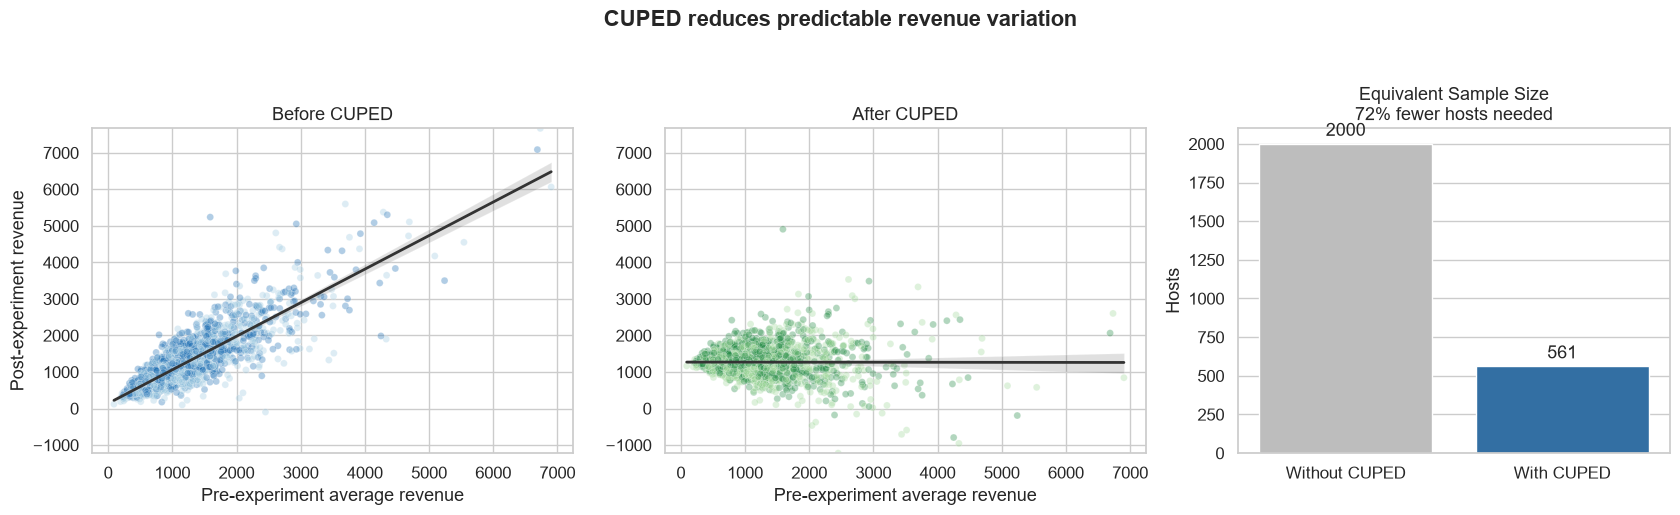

In [5]:
sns.set_theme(style="whitegrid", font_scale=1.1)
 
fig, axes = plt.subplots(
    1, 3,
    figsize=(17, 5),
    gridspec_kw={"width_ratios": [1, 1, 0.9]}
)


# Shared y-axis limits
y_min = min(experiment_data["y_i"].min(), experiment_data["y_cuped"].min())
y_max = max(experiment_data["y_i"].max(), experiment_data["y_cuped"].max())

# Raw revenue
sns.scatterplot(
    data=experiment_data,
    x="Xbar_i",
    y="y_i",
    hue="Treat_i",
    palette={0: "#9ECAE1", 1: "#2171B5"},
    alpha=0.35,
    s=25,
    legend=False,
    ax=axes[0]
)
sns.regplot(
    data=experiment_data,
    x="Xbar_i",
    y="y_i",
    scatter=False,
    color="#333333",
    line_kws={"linewidth": 2},
    ax=axes[0]
)


axes[0].set_title("Before CUPED")
axes[0].set_xlabel("Pre-experiment average revenue")
axes[0].set_ylabel("Post-experiment revenue")
axes[0].set_ylim(y_min, y_max)

# CUPED-adjusted revenue
sns.scatterplot(
    data=experiment_data,
    x="Xbar_i",
    y="y_cuped",
    hue="Treat_i",
    palette={0: "#A1D99B", 1: "#238B45"},
    alpha=0.35,
    s=25,
    legend=False,
    ax=axes[1]
)
sns.regplot(
    data=experiment_data,
    x="Xbar_i",
    y="y_cuped",
    scatter=False,
    color="#333333",
    line_kws={"linewidth": 2},
    ax=axes[1]
)


axes[1].set_title("After CUPED")
axes[1].set_xlabel("Pre-experiment average revenue")
axes[1].set_ylabel("")
axes[1].set_ylim(y_min, y_max)
 
# Sample-size comparison
sample_sizes = pd.DataFrame({
    "Analysis": ["Without CUPED", "With CUPED"],
    "Sample size": [n_original, n_equivalent]
})



sns.barplot(
    data=sample_sizes,
    x="Analysis",
    y="Sample size",
    hue="Analysis",
    palette=["#BDBDBD", "#2171B5"],
    legend=False,
    ax=axes[2]
)
 
axes[2].set_title(f"Equivalent Sample Size\n{variance_reduction:.0%} fewer hosts needed")
axes[2].set_xlabel("")
axes[2].set_ylabel("Hosts")
 
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.0f", padding=3)
 
plt.suptitle(
    "CUPED reduces predictable revenue variation",
    fontsize=16,
    fontweight="bold",
    y=1.03
)
 
plt.tight_layout()
plt.show()

C:\Users\ja21_\AppData\Local\Temp\ipykernel_45120\805163749.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Control", "Treatment"])
C:\Users\ja21_\AppData\Local\Temp\ipykernel_45120\805163749.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Control", "Treatment"])


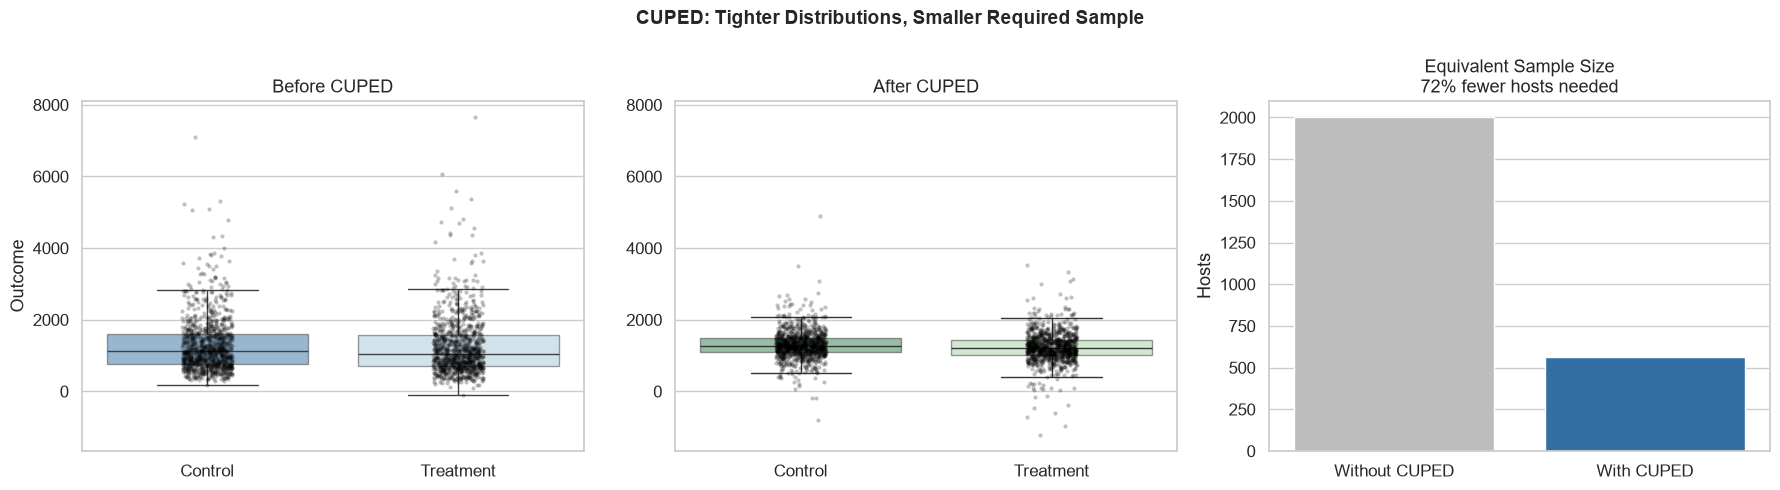

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_data = experiment_data.copy()
plot_data["Treat_i"] = plot_data["Treat_i"].astype(str)

# Shared y-axis limits for the two distribution plots
y_min = min(plot_data["y_i"].min(), plot_data["y_cuped"].min())
y_max = max(plot_data["y_i"].max(), plot_data["y_cuped"].max())
pad = (y_max - y_min) * 0.05

# --- Panel 1: Before CUPED ---
sns.boxplot(
    data=plot_data,
    x="Treat_i",
    y="y_i",
    hue="Treat_i",
    palette={"0": "#9ECAE1", "1": "#2171B5"},
    showfliers=False,
    boxprops=dict(alpha=0.5),
    legend=False,
    ax=axes[0]
)
sns.stripplot(
    data=plot_data,
    x="Treat_i",
    y="y_i",
    color="black",
    alpha=0.25,
    size=3,
    jitter=True,
    ax=axes[0]
)
axes[0].set_title("Before CUPED")
axes[0].set_xlabel("")
axes[0].set_ylabel("Outcome")
axes[0].set_xticklabels(["Control", "Treatment"])
axes[0].set_ylim(y_min - pad, y_max + pad)

# --- Panel 2: After CUPED ---
sns.boxplot(
    data=plot_data,
    x="Treat_i",
    y="y_cuped",
    hue="Treat_i",
    palette={"0": "#A1D99B", "1": "#238B45"},
    showfliers=False,
    boxprops=dict(alpha=0.5),
    legend=False,
    ax=axes[1]
)
sns.stripplot(
    data=plot_data,
    x="Treat_i",
    y="y_cuped",
    color="black",
    alpha=0.25,
    size=3,
    jitter=True,
    ax=axes[1]
)
axes[1].set_title("After CUPED")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_xticklabels(["Control", "Treatment"])
axes[1].set_ylim(y_min - pad, y_max + pad)

# --- Panel 3: Sample-size comparison ---
sample_sizes = pd.DataFrame({
    "Analysis": ["Without CUPED", "With CUPED"],
    "Sample size": [n_original, n_equivalent]
})

sns.barplot(
    data=sample_sizes,
    x="Analysis",
    y="Sample size",
    hue="Analysis",
    palette=["#BDBDBD", "#2171B5"],
    legend=False,
    ax=axes[2]
)
axes[2].set_title(f"Equivalent Sample Size\n{variance_reduction:.0%} fewer hosts needed")
axes[2].set_xlabel("")
axes[2].set_ylabel("Hosts")

plt.suptitle("CUPED: Tighter Distributions, Smaller Required Sample", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()